<a href="https://colab.research.google.com/github/cmburban/MAT-422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

Topics: singular value decomposition, low-rank matrix approximations, principal component analysis

In [17]:
import numpy as np
import matplotlib.pyplot as plt

## 1.4.1 Singular Value Decomposition

Singular value decomposition factors a matrix A into three matrices: U, Sigma, and V.T. The singular values show the importance of the different components of the matrix. SVD is great for understanding matrices, reducing data, and finding low-rank approximations.

In [18]:
A = np.array([
    [4, 0, 2],
    [0, 3, 0],
    [2, 0, 4]
], dtype=float)

U, singular_values, Vt = np.linalg.svd(A)

print("A =")
print(A)

print("\nSingular values:")
print(singular_values)

A =
[[4. 0. 2.]
 [0. 3. 0.]
 [2. 0. 4.]]

Singular values:
[6. 3. 2.]


### Verifying the SVD

The SVD factors A into U, Sigma, and V.T. I can remake the original matrix by multiplying these three components together and compare it with A.

In [19]:
Sigma = np.diag(singular_values)

A_reconstructed = U @ Sigma @ Vt

print("Reconstructed A:")
print(A_reconstructed)

print("\nDifference between A and reconstructed A:")
print(A - A_reconstructed)

Reconstructed A:
[[4. 0. 2.]
 [0. 3. 0.]
 [2. 0. 4.]]

Difference between A and reconstructed A:
[[1.33226763e-15 0.00000000e+00 1.99840144e-15]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.88178420e-16 0.00000000e+00 1.33226763e-15]]


The remade matrix is the same as the original matrix. The small differences are due to  numerical rounding, which shows that the SVD reconstruction works correctly.

### Verifying Orthogonality

The columns of U and V should be orthonormal. I can check this by multiplying U.T @ U and V.T @ V. Both results should be about the identity matrix.

In [20]:
print("U.T @ U:")
print(U.T @ U)

print("\nV.T @ V:")
print(Vt @ Vt.T)

U.T @ U:
[[1.00000000e+00 0.00000000e+00 1.33393446e-16]
 [0.00000000e+00 1.00000000e+00 0.00000000e+00]
 [1.33393446e-16 0.00000000e+00 1.00000000e+00]]

V.T @ V:
[[ 1.00000000e+00  0.00000000e+00 -1.01465364e-17]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-1.01465364e-17  0.00000000e+00  1.00000000e+00]]


The results are identity matrices, showing that the singular vectors are orthonormal.

### Visualizing the Singular Values

A bar chart makes it easier to compare the sizes of the singular values. Larger singular values represent parts that contribute more to the structure of the matrix.

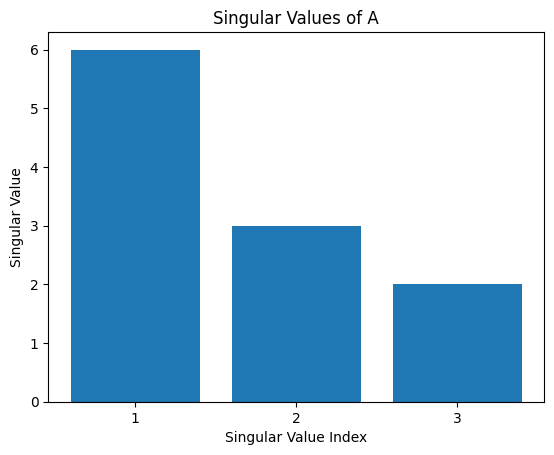

In [21]:
plt.bar(range(1, len(singular_values) + 1), singular_values)

plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of A")
plt.xticks(range(1, len(singular_values) + 1))
plt.show()

The plot shows that the singular values are not all the same size. The larger singular values represent the parts that contribute more strongly to the matrix. This will be useful when creating a low-rank approximation.

## 1.4.2 Low-Rank Matrix Approximation

A low-rank approximation uses only some of the largest singular values and their corresponding singular vectors. This creates a simpler version of the original matrix while trying to preserve its most important information.

### Rank-1 Approximation

I will first keep only the largest singular value. This gives a rank-1 approximation of the original matrix.

In [22]:
rank_1 = singular_values[0] * np.outer(U[:, 0], Vt[0, :])

print("Rank-1 approximation:")
print(rank_1)

Rank-1 approximation:
[[ 3. -0.  3.]
 [-0.  0. -0.]
 [ 3. -0.  3.]]


The rank-1 approximation uses only the most important singular piece of the matrix. It is simpler than the original matrix, but some info is lost.

### Rank-2 Approximation

I can improve the approximation by keeping the two largest singular values instead of only one.

In [23]:
rank_2 = (
    singular_values[0] * np.outer(U[:, 0], Vt[0, :])
    + singular_values[1] * np.outer(U[:, 1], Vt[1, :])
)

print("Rank-2 approximation:")
print(rank_2)

Rank-2 approximation:
[[ 3. -0.  3.]
 [ 0.  3. -0.]
 [ 3. -0.  3.]]


The rank-2 approximation keeps two singular pieces, so it should preserve more info from the original matrix than the rank-1 approximation.

### Comparing Approximation Errors

I can use the Frobenius norm of the difference between A and each approximation to measure the reconstruction error. A smaller error means the approximation is closer to the original matrix.

In [24]:
error_rank_1 = np.linalg.norm(A - rank_1, 'fro')
error_rank_2 = np.linalg.norm(A - rank_2, 'fro')

print("Rank-1 approximation error:", error_rank_1)
print("Rank-2 approximation error:", error_rank_2)

Rank-1 approximation error: 3.6055512754639896
Rank-2 approximation error: 2.0


The rank-2 approximation has a smaller reconstruction error than the rank-1 approximation. This shows that keeping an additional singular component improves the approximation.

### Visualizing the Approximation Errors

The following bar chart compares the reconstruction errors for the rank-1 and rank-2 approximations.

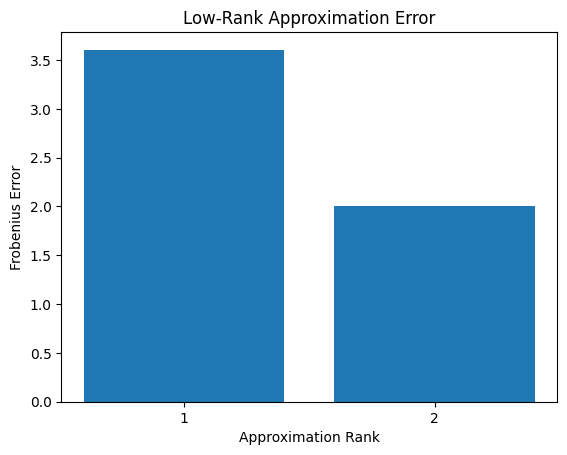

In [25]:
ranks = [1, 2]
errors = [error_rank_1, error_rank_2]

plt.bar(ranks, errors)

plt.xlabel("Approximation Rank")
plt.ylabel("Frobenius Error")
plt.title("Low-Rank Approximation Error")
plt.xticks(ranks)
plt.show()

The chart shows that the reconstruction error decreases when moving from rank 1 to rank 2. This demonstrates why additional singular components can provide a better approximation of the original matrix.

## 1.4.3 Principal Component Analysis

Principal component analysis (PCA) can be viewed as applying SVD to centered data. PCA finds directions that capture the most variation in the data. The first principal component captures the largest amount of variation, while later components capture less.

### Creating the Dataset

I will use a small dataset with two correlated features. The correlation makes it easier to see the main direction of the data.

In [26]:
X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 7],
    [6, 8],
    [7, 9]
], dtype=float)

print("Original data:")
print(X)

Original data:
[[2. 3.]
 [3. 4.]
 [4. 5.]
 [5. 7.]
 [6. 8.]
 [7. 9.]]


### Centering the Data

Before applying SVD for PCA, I need to center each feature by subtracting its mean. This moves the center of the dataset to the origin.

In [27]:
means = np.mean(X, axis=0)
X_centered = X - means

print("Feature means:")
print(means)

print("\nCentered data:")
print(X_centered)

Feature means:
[4.5 6. ]

Centered data:
[[-2.5 -3. ]
 [-1.5 -2. ]
 [-0.5 -1. ]
 [ 0.5  1. ]
 [ 1.5  2. ]
 [ 2.5  3. ]]


The centered data has a mean of approximately zero for each feature. Centering the data allows PCA to focus on the directions in which the data varies.

### Applying SVD to the Centered Data

PCA can be calculated using the SVD of the centered data. The rows of V.T give the principal directions of the dataset.

In [28]:
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)

print("Singular values:")
print(s_pca)

print("\nPrincipal directions:")
print(Vt_pca)

Singular values:
[6.73555844 0.36366543]

Principal directions:
[[ 0.61962948  0.78489445]
 [-0.78489445  0.61962948]]


The first principal direction corresponds to the largest singular value, so it represents the direction that captures the most variation in the dataset.

### Explained Variance

The singular values can be used to calculate the proportion of variance explained by each principal component. This shows how important each component is for describing the data.

In [29]:
explained_variance_ratio = s_pca**2 / np.sum(s_pca**2)

print("Explained variance ratio:")
print(explained_variance_ratio)

print("\nTotal explained variance:")
print(np.sum(explained_variance_ratio))

Explained variance ratio:
[0.99709335 0.00290665]

Total explained variance:
1.0


The first principal component explains most of the variation in the dataset. This means that much of the information in the two-dimensional data can be represented using a single principal direction.

### Projecting the Data onto the Principal Components

The principal component scores are found by projecting the centered data onto the principal directions. This changes the coordinates of the data from the original feature space to the PCA coordinate system.

In [30]:
scores = X_centered @ Vt_pca.T

print("PCA scores:")
print(scores)

PCA scores:
[[-3.90375707  0.10334768]
 [-2.49923313 -0.06191729]
 [-1.0947092  -0.22718226]
 [ 1.0947092   0.22718226]
 [ 2.49923313  0.06191729]
 [ 3.90375707 -0.10334768]]


The PCA scores show where each data point lies along the principal component directions. The first column contains the coordinates along PC1, which captures most of the variation.

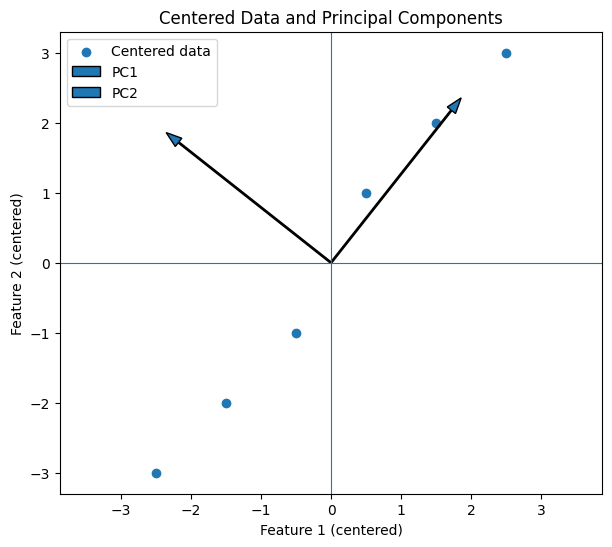

In [32]:
plt.figure(figsize=(7, 6))

plt.scatter(X_centered[:, 0], X_centered[:, 1], label="Centered data")

scale = 3

plt.arrow(
    0, 0,
    scale * Vt_pca[0, 0],
    scale * Vt_pca[0, 1],
    width=0.02,
    head_width=0.15,
    length_includes_head=True,
    label="PC1"
)

plt.arrow(
    0, 0,
    scale * Vt_pca[1, 0],
    scale * Vt_pca[1, 1],
    width=0.02,
    head_width=0.15,
    length_includes_head=True,
    label="PC2"
)

plt.xlabel("Feature 1 (centered)")
plt.ylabel("Feature 2 (centered)")
plt.title("Centered Data and Principal Components")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.axis("equal")
plt.show()

The plot shows that PC1 points mainly in the direction where the data varies the most. PC2 is perpendicular to PC1 and shows the rest of the variation in the data.

### Visualizing the PCA Projection

The projected data can be plotted using PC1 and PC2 as the new axes. This shows the data in the coordinate system made by PCA.

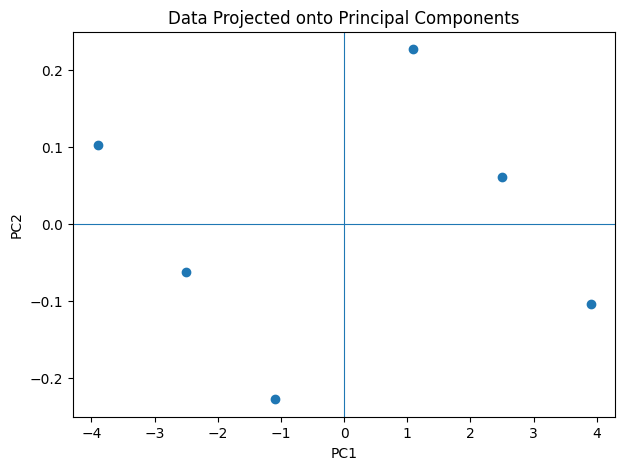

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(scores[:, 0], scores[:, 1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data Projected onto Principal Components")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()

The projection shows that the data is more concentrated along PC1 than PC2. Since PC1 explains most of the variance, it shows a good summary of the original two-feature dataset.

## End of Notebook Reflection

This week I learned how SVD can break a matrix into smaller parts that are easier to understand. I also learned that the singular values show which parts of the matrix are more important. By keeping only the largest singular values, I was able to make low-rank approximations of the original matrix. The rank-2 approximation was closer to the original than the rank-1 approximation because it kept more information.

I also learned how PCA uses centered data to find the directions where the data changes the most. In my example, the first principal component explained most of the variation in the data. This showed me how PCA can be useful for reducing the number of features while still keeping most of the important information. Overall, this notebook helped me understand how SVD and PCA can be used to simplify and study data.

## Reference

[Mathematical Methods in Data Science - Elsevier (2023)](https://doi.org/10.1016/B978-0-44-318679-0.00007-7)

[Numpy - Singular Value Decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)

[Matplotlib](https://matplotlib.org/stable/)

[OpenAI - ChatGPT (2026)](https://chatgpt.com)

## Checklist

I explained each concept in words before or after the code. [DONE]

I verified important claims numerically, such as dot products, norms, identities, or residuals. [DONE]

I changed or extended at least one example so the notebook reflects my own work. [DONE]

I ran the notebook from top to bottom without errors. [DONE]

I saved the notebook from Google Colab directly to GitHub, following the course instructions. [DONE]